# Eviny Charging Curve Classification LSTM 
#### by Sebastian Einar Salas Røkholt
----

### Index
**1. Setup** </br>
**2. Data Exploration, Wrangling and Preprocessing**</br>
**3. Modelling**</br>
**4. Model Evaluation and Selection**</br>
**+++**</br>


### Introduction
The aim of this notebook is ...

 ### 1. Setup

In [ ]:
import os
import gc
import math
import random
import tempfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from typing import Tuple, List
from dataclasses import dataclass
from collections import OrderedDict
import torch
import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import DataLoader, Dataset, Sampler
import torch.nn.utils.rnn as rnn_utils
from torch.amp import autocast
import ray
from ray import tune
from ray.air import session
from ray.train import Checkpoint  # TODO: update this import to newest version
from ray.tune.schedulers import HyperBandForBOHB
from ray.tune.search.bohb import TuneBOHB
from ray.tune.tuner import Tuner, TuneConfig, RunConfig
from ray.tune import ExperimentAnalysis
import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error

# Notebook global constants
RANDOM_SEED = 42
TRAIN_MODEL = True
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, 'Models')
MODEL_NAME = 'LSTM_multihorizon_raytuned_model_6.pth'
MODEL_PATH = os.path.join(MODEL_FOLDER_PATH, MODEL_NAME)
RAY_TUNE_FOLDER_NAME = "bohb_lstm_tuning_run_6"
RAY_TUNE_RUN_FOLDER_PATH = os.path.join(MODEL_FOLDER_PATH, RAY_TUNE_FOLDER_NAME)
BATCH_SIZE = 256
NUM_WORKERS = 6
HORIZON = 5 

# Package and notebook settings
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.benchmark = True
ray.shutdown()
ray.init(ignore_reinit_error=True)
sns.set_theme(style="whitegrid")
%matplotlib inline
pd.options.mode.copy_on_write = True
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = '{:.2f}'.format

2025-08-18 14:49:18,983	INFO worker.py:1927 -- Started a local Ray instance.


(tune_train_model pid=28281) /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/linux_venv/lib64/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
(tune_train_model pid=28281)   warnings.warn(
(tune_train_model pid=28281) /tmp/ipykernel_24417/2794594451.py:332: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1750])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
(tune_train_model pid=28281) /tmp/ipykernel_24417/2794594451.py:335: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1750])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
(tune_train_model pid=28281) /tmp/ipykernel_24417/2794594451.py:332: UserWarning: Using a target siz

In [5]:
print("[trial] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[trial] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))

[trial] CUDA available: True
[trial] Device: NVIDIA GeForce RTX 4070 Laptop GPU


#### 1.1 Feature selection 
In order to predict `soc` and `power` output for the next `HORIZON` (e.g. 5) timesteps, the model will use the `soc` and `power` values from the `sequence_length` (e.g. 15) previous timesteps/minutes. In addition, there are two static (non time-dependent, per-session) features that we believe the model will use to enhance its predictive abilities. The first static feature is `temp`, the approximate ambient temperature (rounded to the nearest integer) at the start of the charging session. Charging speed is directly influenced by the vehicle's battery temperature, because at lower temperatures, the chemical processes in the battery slow down. Lithium-ion batteries may also experience lithium plating if charged to quickly at low temperatures, so both vehicle and charging station manufacturers place automatic restrictions that limit the energy transfer. As we do not have access to battery temperature data from each vehciel, we have collected ambient air temperature  data instead, which we believe might be a good explanatory environmental variable as the ambient temperature is one of several causal factors that influence the battery temperature. Other factors are vehicle usage, charging duration, and the vehicle's thermal management system.
The second static feature we will be using is `nominal_power`, which is the charging station's maximum power output as stated by the manufacturer. As different types of charging stations are likely to have significantly different power output distributions, we believe that this static feature will help the model determine what the likely value range will be, especially at the start of the charging session. 

The dataset contains a few other features, but these will not be used for modelling. This is mainly, because these features are either derived from other features or were used in the feature engineering step to calculate other derived features. For example, `energy` (in kWh) is simply the `power` (in kW) aggregated to the hour, while `lat` (latitude) and `lon` (longitude) were used to retrieve temperature data. The geographical position of the charging station is unlikely to be a useful predictor for our target variables. 

In [6]:
# Load the cleaned dataframe
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
print(f"Features: {df.columns}")

all_features = ["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]
fixed_features = ["temp", "nominal_power"]
target_features = ["power", "soc"]
input_features = fixed_features + target_features  # 4 columns: [temp, nominal_power, power, soc]

df = df[all_features]
df.head()


Features: Index(['charging_id', 'timestamp', 'minutes_elapsed', 'soc', 'power', 'energy',
       'charger_category', 'nominal_power', 'temp', 'lat', 'lon'],
      dtype='object')


,charging_id,minutes_elapsed,power,soc,temp,nominal_power
0,0,0,89.44,40.00,4,150.00
1,0,1,92.75,41.00,4,150.00
2,0,2,94.81,43.00,4,150.00
3,0,3,95.68,45.00,4,150.00
4,0,4,96.88,47.00,4,150.00


In [7]:
df.tail()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power
1590118,12657311,11,126.05,57.00,7,360.00
1590119,12657311,12,126.95,60.00,7,360.00
1590120,12657311,13,127.97,62.00,7,360.00
1590121,12657311,14,128.01,65.00,7,360.00
1590122,12657311,15,129.47,67.00,7,360.00


More feature engineering - move this to notebook 01!

In [8]:
# Load the cleaned dataframe
df = pd.read_parquet("../Data/etron55-charging-sessions.parquet")
print(f"Features: {df.columns}")

# --- Base columns we’ll keep for modeling ---
base_cols = ["charging_id", "minutes_elapsed", "power", "soc", "temp", "nominal_power"]
df = df[base_cols].copy()

# ========= Feature engineering (all done in ORIGINAL units) =========
# 1) Progress (online-known): log-scaled minutes (0..1) that doesn’t need a per-session future.
df["progress"] = np.log1p(df["minutes_elapsed"]) / np.log1p(120.0)  # clamp-free, ~[0,1+]

# 2) Relative power: easier cross-site learning.
#    Safe denominator + clip to [0, 1.2], then normalize to [0,1].
denom = np.clip(df["nominal_power"].astype(float).values, 1e-6, None)
rel = (df["power"].astype(float).values / denom)
rel = np.clip(rel, 0.0, 1.2)
df["rel_power"] = rel / 1.2  # → [0,1]

# 3) Local dynamics (per-session): one-step deltas in ORIGINAL units
#    (we’ll scale these later with a dedicated MinMax fitted on TRAIN only)
df["d_power"] = df.groupby("charging_id", observed=False)["power"].diff().fillna(0.0)
df["d_soc"]   = df.groupby("charging_id", observed=False)["soc"].diff().fillna(0.0)

# Optional: short EMA of the deltas (span=3)
df["d_power_ema3"] = df.groupby("charging_id", observed=False)["d_power"] \
                        .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)
df["d_soc_ema3"]   = df.groupby("charging_id", observed=False)["d_soc"] \
                        .transform(lambda s: s.ewm(span=3, adjust=False).mean()).fillna(0.0)

# 4) Charger category one-hot (coarse, not sparse): bin nominal power
#    bins: 0–75 (low), 75–200 (mid), >200 (high)
bins   = [0, 75, 200, np.inf]
labels = ["low", "mid", "high"]
df["charger_cat_bin"] = pd.cut(df["nominal_power"].astype(float), bins=bins,
                               labels=labels, include_lowest=True, right=True)
charger_ohe = pd.get_dummies(df["charger_cat_bin"], prefix="charger_cat", dtype=np.float32)
if charger_ohe.shape[1] == 0:
    # just in case (shouldn’t happen): create empty columns consistently
    charger_ohe = pd.DataFrame(0.0, index=df.index,
                               columns=["charger_cat_low","charger_cat_mid","charger_cat_high"])
df = pd.concat([df.drop(columns=["charger_cat_bin"]), charger_ohe], axis=1)
charger_ohe_cols = charger_ohe.columns.tolist()  # keep names for input_features

# ========= Feature lists =========
# Static features we’ll MinMax-scale: only continuous static ones (leave OHE as-is to avoid degenerate scaling)
fixed_features = ["temp", "nominal_power"]

# Targets remain the same
target_features = ["power", "soc"]

# Dynamic extra features (already in ~[0,1] except deltas; we’ll scale deltas in Cell B)
dynamic_extra_features = ["progress", "rel_power", "d_power", "d_soc", "d_power_ema3", "d_soc_ema3"]

# Final model inputs = static + OHE + original dynamics (power/soc) + new dynamic helpers
input_features = fixed_features + charger_ohe_cols + target_features + dynamic_extra_features

print("New input_features:", input_features[:10], "... (total =", len(input_features), ")")
df.head()


Features: Index(['charging_id', 'timestamp', 'minutes_elapsed', 'soc', 'power', 'energy',
       'charger_category', 'nominal_power', 'temp', 'lat', 'lon'],
      dtype='object')
New input_features: ['temp', 'nominal_power', 'charger_cat_low', 'charger_cat_mid', 'charger_cat_high', 'power', 'soc', 'progress', 'rel_power', 'd_power'] ... (total = 13 )


,charging_id,minutes_elapsed,power,soc,temp,nominal_power,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,89.44,40.00,4,150.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,92.75,41.00,4,150.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,1.00,0.00
2,0,2,94.81,43.00,4,150.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,1.00,0.00
3,0,3,95.68,45.00,4,150.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,1.00,0.00
4,0,4,96.88,47.00,4,150.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,1.00,0.00


## 2 - Data preparation

#### 2.1 - Splitting the data 
The code below splits the dataset into training, validation and test sets. </br>
`GroupShuffleSplit` ensures that a charging session isn't split across multiple sets.

In [9]:
def split_data(df: pd.DataFrame, test_size: float=0.2, validation_size: float=0.1) \
    -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Split the dataset into train, validation, and test sets by charging_id grouping.
    
    :param df: Original dataframe containing all charging sessions
    :param test_size: Proportion of data to use for testing
    :param validation_size: Proportion of the remaining data (after test split) to use for validation
    :return: train_df, val_df, test_df DataFrames
    """
    #Test split
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df['charging_id']))
    train_val_df = df.iloc[train_val_idx]

    # Validation split
    adj_val_size = validation_size / (1 - test_size)  # Adjust validation size based on the remaining dataset after test split
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df['charging_id']))

    # Performs the splits on the original dataset
    train_df = train_val_df.iloc[train_idx]
    val_df = train_val_df.iloc[val_idx]
    test_df = df.iloc[test_idx]
    return train_df, val_df, test_df


train_df, val_df, test_df = split_data(df)
print(f"Training set size: {len(train_df)} ({round(100*(len(train_df)/len(df)), 1)}%)\n"
      f"Validation set size: {len(val_df)} ({round(100*(len(val_df)/len(df)), 1)}%)\n"
      f"Test set size: {len(test_df)} ({round(100*(len(test_df)/len(df)), 1)}%)\n"
      f"Total size: {len(df)}")


Training set size: 1113061 (70.0%)
Validation set size: 159426 (10.0%)
Test set size: 317636 (20.0%)
Total size: 1590123


In [10]:
train_df.head()

,charging_id,minutes_elapsed,power,soc,temp,nominal_power,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,89.44,40.00,4,150.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,92.75,41.00,4,150.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,1.00,0.00
2,0,2,94.81,43.00,4,150.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,1.00,0.00
3,0,3,95.68,45.00,4,150.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,1.00,0.00
4,0,4,96.88,47.00,4,150.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,1.00,0.00


#### 2.2 - Data normalisation


In [11]:
# --- Scalers ---
fixed_features_scaler = MinMaxScaler(feature_range=(0, 1))  # for ["temp","nominal_power"]
power_scaler = MinMaxScaler(feature_range=(0, 1))            # for target+input "power"
soc_scaler   = MinMaxScaler(feature_range=(0, 1))            # for target+input "soc"

# Delta features (original units) will be scaled to [0,1] using TRAIN only
delta_features = ["d_power", "d_soc", "d_power_ema3", "d_soc_ema3"]
delta_scaler   = MinMaxScaler(feature_range=(0, 1))

# --- Fit on TRAIN ONLY ---
fixed_features_scaler.fit(train_df[fixed_features])
power_scaler.fit(train_df[["power"]])
soc_scaler.fit(train_df[["soc"]])
delta_scaler.fit(train_df[delta_features])

def apply_scaling(df: pd.DataFrame):
    # static continuous
    df[fixed_features] = fixed_features_scaler.transform(df[fixed_features])
    # targets/dynamics that we also use as inputs
    df["power"] = power_scaler.transform(df[["power"]])
    df["soc"]   = soc_scaler.transform(df[["soc"]])
    # local dynamics (deltas/EMAs)
    df[delta_features] = delta_scaler.transform(df[delta_features])
    return df

# Transform train, val, test sets
train_df = apply_scaling(train_df)
val_df   = apply_scaling(val_df)
test_df  = apply_scaling(test_df)

# Constants to be used inside the training loop
POWER_MIN = float(power_scaler.data_min_[0])
POWER_MAX = float(power_scaler.data_max_[0])
SOC_MIN   = float(soc_scaler.data_min_[0])
SOC_MAX   = float(soc_scaler.data_max_[0])


 ### 2.3 - Building the datasets and data loaders

 Write a description here

In [12]:
class ChargingSessionDataset(Dataset):
    """A custom PyTorch Dataset class to represent a dataset of charging sessions (sequences), 
    where each session is returned as (X, y, length). The dataset is grouped by charging_id.
    For each session, we store:
        X shape = (L, input_size)
        Y shape = (L, horizon, num_target_feats)
                    where Y[i] is the next 'horizon' steps 
                    (power, soc) after time i.
        length:  scalar int. The length of the sequence / duration of the charging session in minutes
    PS: We later mask out invalid timesteps when calculating the loss.
    """
    def __init__(self,
                 df: pd.DataFrame, input_features: List[str], target_features: List[str], horizon: int=5):
        super().__init__()
        self.input_features = input_features
        self.target_features = target_features
        self.horizon = horizon
        self.num_targets = len(target_features)
        self.sessions = []

        # Group by charging session
        for session_id, session_df in df.groupby('charging_id', observed=False):
            session_df = session_df.sort_values('minutes_elapsed')
            X = session_df[self.input_features].values  # shape: (L, input_size)
            Y_raw = session_df[self.target_features].values  # shape: (L, num_targets)
            L = len(X)

            if L < (self.horizon + 1):
                # Not enough length to produce at least 1 valid horizon step 
                # after skipping i=0 => effectively yields zero valid points for training. 
                # We still can store it or skip. Usually we skip it.
                continue

            # Build Y_horizon: shape (L, horizon, num_targets)
            Y_horizon = np.zeros((L, self.horizon, self.num_targets), dtype=np.float32)
            for i in range(L):
                for h in range(1, self.horizon + 1):
                    future_idx = i + h
                    if future_idx < L:
                        # Predict residual targets in the same scaled space
                        # Δy(i→i+h) = y(i+h) - y(i)   for each target (power, soc)
                        Y_horizon[i, h-1] = (Y_raw[future_idx] - Y_raw[i])
                    else:
                        # If we are out of range, remain zeros 
                        # (the step i is considered invalid in the loss anyway if i >= L - horizon)
                        pass

            self.sessions.append((X.astype(np.float32), Y_horizon))

    def __len__(self):
        return len(self.sessions)

    def __getitem__(self, idx):
        X, Y = self.sessions[idx]
        length = X.shape[0]
        return X, Y, length


class BucketBatchSampler(Sampler):
    """
    Groups charging sessions of similar length into batches to reduce padding.
    """
    def __init__(self, dataset: ChargingSessionDataset, batch_size: int, shuffle: bool=True):
        """
        Args:
            dataset (ChargingSessionDataset): Dataset to sample from.
            batch_size (int): Number of sessions per batch.
            shuffle (bool): If True, shuffles batches at initialization and every epoch.
        """
        self.dataset = dataset
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        # Sorts the dataset indices by session length (asc)
        lengths = [(i, dataset.sessions[i][0].shape[0]) for i in range(len(dataset))]
        self.sorted_indices = sorted(lengths, key=lambda x: x[1])
        self.sorted_indices = [tup[0] for tup in self.sorted_indices]

        # Chunks the sequences into batches
        self.batches = []
        for i in range(0, len(self.sorted_indices), self.batch_size):
            self.batches.append(self.sorted_indices[i : i + self.batch_size])
        
        if self.shuffle:
            # at instanciation, we shuffle the batches
            random.shuffle(self.batches)

    def __iter__(self):
        """Yields batches of indices, optionally shuffled per epoch."""
        if self.shuffle:
            # re-shuffles the batch order every epoch
            random.shuffle(self.batches)
        for batch_inds in self.batches:
            yield batch_inds

    def __len__(self):
        return math.ceil(len(self.sorted_indices) / self.batch_size)


def session_collate_fn(batch: List[Tuple[np.ndarray, np.ndarray, int]]):
    """
    Pads sequences to the same length and converts them into tensors for batch processing.

    Args:
        batch: List of tuples containing (X, y, session length) for each session.

    Returns: Tuple of three tensors: (padded_X, padded_Y, lengths).
      - padded_X: (B, T_max, input_size)
      - padded_Y: (B, T_max, horizon, num_targets)
      - lengths: Tensor of session lengths with shape (batch_size,).

    """
    all_x, all_y, lengths = zip(*batch)
    max_len = max(lengths)
    horizon = all_y[0].shape[1]
    num_targets = all_y[0].shape[2]
    input_size = all_x[0].shape[1]
    padded_X = []
    padded_Y = []

    for x, y, seq_len in zip(all_x, all_y, lengths):
        X_pad = np.zeros((max_len, input_size), dtype=np.float32)
        Y_pad = np.zeros((max_len, horizon, num_targets), dtype=np.float32)
        X_pad[:seq_len, :] = x
        Y_pad[:seq_len, :, :] = y
        padded_X.append(X_pad)
        padded_Y.append(Y_pad)

    # converts list of ndarrays -> single ndarray -> tensor
    padded_X = torch.from_numpy(np.stack(padded_X, axis=0)).float()
    padded_Y = torch.from_numpy(np.stack(padded_Y, axis=0)).float()
    lengths = torch.tensor(lengths, dtype=torch.long)

    return padded_X, padded_Y, lengths

In [13]:
# Create the Datasets
train_dataset = ChargingSessionDataset(train_df, input_features, target_features, horizon=HORIZON)
val_dataset   = ChargingSessionDataset(val_df,   input_features, target_features, horizon=HORIZON)
test_dataset  = ChargingSessionDataset(test_df,  input_features, target_features, horizon=HORIZON)


In [14]:
# df = None; gc.collect()

 ## 3. Modelling

 We will now define a multivariate LSTM architecture for a model that can predict the next `HORIZON` time steps for each variable-length input sequence. The LSTM layers produce hidden states for each time step `(B, T, HIDDEN_DIM)`. We then apply a dense/linear layer to each hidden state to produce `HORIZON * num_targets` outputs. Finally, we reshape to `(B, T, HORIZON, num_targets`.

### 3.1 Architecture

In [15]:
class MultiHorizonLSTM(nn.Module):
    """
    LSTM that, for each time step i, outputs the next H horizon steps 
    of multiple targets (e.g. power, soc).
    """
    def __init__(self, input_size: int, hidden_dim: int, horizon: int, num_targets: int,
                 num_layers: int, dropout: float = 0.0):
        super(MultiHorizonLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.horizon = horizon
        self.num_targets = num_targets

        # Dropout in nn.LSTM is applied between layers → only effective if num_layers > 1
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.linear = nn.Linear(hidden_dim, horizon * num_targets)

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        packed_x = rnn_utils.pack_padded_sequence(
            x, seq_lengths, batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed_x)
        out, out_lengths = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        out = self.linear(out).view(out.shape[0], out.shape[1], self.horizon, self.num_targets)
        return out, out_lengths


### 3.2 Training with Ray Tune & BOHB
In this section we define a new training function compatible with Ray Tune, 
and then launch a BOHB hyperparameter search. 


In [16]:
# --- Global column indices (used in training/tuning loop and plotting) ---
IDX_TEMP  = input_features.index("temp")
IDX_NOM   = input_features.index("nominal_power")
IDX_POWER = input_features.index("power")
IDX_SOC   = input_features.index("soc")

# Helper functions
def _build_adamw(named_params, lr, weight_decay):
    """
    AdamW with bias/1D params excluded from weight decay.
    named_params: iterable[(name, param)]
    """
    decay, no_decay = [], []
    for n, p in named_params:
        if not p.requires_grad:
            continue
        (decay if p.ndim > 1 else no_decay).append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay},
         {"params": no_decay, "weight_decay": 0.0}],
        lr=lr
    )

try:
    from ray import ObjectRef  # type: ignore
except Exception:  # older Ray may export it elsewhere; fall back to a duck-typing check
    ObjectRef = tuple()  # harmless sentinel

def _resolve_dataset_ref(maybe_ref):
    """Return a ChargingSessionDataset instance from an ObjectRef or pass-through instance.
    Raise a clear error if someone passed the class object by mistake."""
    # Case 1: it's an ObjectRef -> fetch
    if isinstance(maybe_ref, ObjectRef):
        return ray.get(maybe_ref)
    # Case 2: user already handed us a dataset instance
    # Avoid importing your class here (keeps pickles small); do a duck-type check
    if hasattr(maybe_ref, "__len__") and hasattr(maybe_ref, "__getitem__"):
        return maybe_ref
    # Case 3: they accidentally passed the *class* (ChargingSessionDataset) or something else
    if isinstance(maybe_ref, type):
        raise ValueError(
            "Got a class instead of a dataset instance/ObjectRef. "
            "Make sure you pass `ray.put(train_dataset)` / `ray.put(val_dataset)` "
            "via `tune.with_parameters(...)`."
        )
    raise ValueError(
        f"Invalid dataset ref of type {type(maybe_ref)}. "
        "Pass an ObjectRef from ray.put(dataset) or a dataset instance."
    )


class UncertaintyWeights(nn.Module):
    """
    Learnable balancing between POWER and SOC losses
    (Kendall & Gal, 2018). Works with any per-target losses.
    """
    def __init__(self):
        super().__init__()
        self.log_var_power = nn.Parameter(torch.tensor(0.0))
        self.log_var_soc   = nn.Parameter(torch.tensor(0.0))

    def forward(self, loss_power, loss_soc):
        prec_p = torch.exp(-self.log_var_power)  # 1 / sigma^2
        prec_s = torch.exp(-self.log_var_soc)
        return 0.5 * (prec_p * loss_power + prec_s * loss_soc) + 0.5 * (self.log_var_power + self.log_var_soc)

def _horizon_weights(H: int, alpha: float, device: torch.device):
    """
    Exponential weights: w[h] = exp(-alpha*(h-1)), h ∈ {1..H}
    Returned shape: (1,1,H,1) for broadcasting over (B,T,H,C)
    """
    w = torch.exp(-alpha * torch.arange(1, H+1, device=device, dtype=torch.float32))
    return w.view(1, 1, H, 1)


def inv_minmax_channel_torch(t_scaled: torch.Tensor,
                             min_val: torch.Tensor,
                             max_val: torch.Tensor,
                             ch: int) -> torch.Tensor:
    """
    Differentiable inverse MinMax for one channel of a (B,T,H,C) tensor.
    x = y * (max - min) + min
    Returns (B,T,H,1).
    """
    return t_scaled[..., ch:ch+1] * (max_val - min_val) + min_val


def _vectorized_mask(lengths: torch.Tensor, T_max: int, horizon: int, device):
    """
    Valid time steps i satisfy: 1 <= i < (len - horizon).
    Returns:
      mask_4d: (B, T_max, H, 1) boolean — ready to broadcast over target dim.
    """
    B = lengths.shape[0]
    t = torch.arange(T_max, device=device).unsqueeze(0).expand(B, -1)   # (B, T)
    end = lengths.to(device).unsqueeze(1) - horizon                      # (B, 1)
    mask_2d = (t >= 1) & (t < end)                                       # (B, T)

    # Build (B, T, H) then (B, T, H, 1)
    mask_3d = mask_2d.unsqueeze(-1).expand(-1, -1, horizon)              # (B, T, H)
    mask_4d = mask_3d.unsqueeze(-1)                                      # (B, T, H, 1)
    return mask_4d

def reconstruct_abs_from_residuals_batch(
    pred_resid: torch.Tensor,    # (B, T, H, C) residual predictions in *scaled* space
    X_batch: torch.Tensor,       # (B, T, input_size) inputs in *scaled* space
    idx_power: int,
    idx_soc: int
) -> torch.Tensor:
    """
    Return absolute predictions y_hat(i+h) in *scaled* space:
      y_hat_abs = Δy_hat + y(i)
    """
    base = torch.stack([X_batch[..., idx_power], X_batch[..., idx_soc]], dim=-1)  # (B, T, C)
    base = base.unsqueeze(2)                                                      # (B, T, 1, C)
    return pred_resid + base                                                      # broadcast over H


def reconstruct_abs_from_bundle(
    bundle: "SampleBundle", idx_power: int, idx_soc: int
) -> torch.Tensor:
    """
    Convenience for plotting: from one bundle (single sample), return (T, H, C)
    absolute predictions in *scaled* space.
    """
    base = bundle.X_sample[:, [idx_power, idx_soc]]    # (T, C) scaled inputs at time i
    base = base.unsqueeze(1)                            # (T, 1, C)
    return bundle.P_sample + base                       # (T, H, C)


def _per_target_rmse(pred, y_true, mask_4d):
    # pred, y_true: (B, T, H, C); mask_4d: (B, T, H, 1)
    mask_3d = mask_4d.squeeze(-1)                                        # (B, T, H)
    B, T, H, C = pred.shape
    rmses = []
    for k in range(C):
        se_k = (pred[..., k] - y_true[..., k]) ** 2                      # (B, T, H)
        valid_k = se_k[mask_3d]                                          # 1D over valid positions
        if valid_k.numel() == 0:
            rmses.append(float("nan"))
        else:
            rmses.append(torch.sqrt(valid_k.mean()).item())
    return rmses


def _build_loaders_for_trial(batch_size: int):
    """Rebuilds samplers/loaders per trial so we can tune batch size."""
    train_sampler_local = BucketBatchSampler(train_dataset, batch_size=batch_size, shuffle=True)
    val_sampler_local   = BucketBatchSampler(val_dataset,   batch_size=batch_size, shuffle=False)

    train_loader_local = DataLoader(
        train_dataset, batch_sampler=train_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader_local = DataLoader(
        val_dataset, batch_sampler=val_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2,
        persistent_workers=(NUM_WORKERS > 0)
    )
    return train_loader_local, val_loader_local


def _build_loaders_for_trial_from_datasets(train_dataset_local, val_dataset_local, batch_size: int):
    """Build loaders from explicit dataset objects (no globals)."""
    train_sampler_local = BucketBatchSampler(train_dataset_local, batch_size=batch_size, shuffle=True)
    val_sampler_local   = BucketBatchSampler(val_dataset_local,   batch_size=batch_size, shuffle=False)

    train_loader_local = DataLoader(
        train_dataset_local, batch_sampler=train_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2,
        persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader_local = DataLoader(
        val_dataset_local, batch_sampler=val_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2,
        persistent_workers=(NUM_WORKERS > 0)
    )
    return train_loader_local, val_loader_local


# Training and tuning function
def tune_train_model(config, checkpoint_dir=None, train_dataset_ref=None, val_dataset_ref=None):    
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # put scaler bounds on the correct device once
    pmin = torch.tensor(POWER_MIN, device=device)
    pmax = torch.tensor(POWER_MAX, device=device)
    smin = torch.tensor(SOC_MIN,   device=device)
    smax = torch.tensor(SOC_MAX,   device=device)

    hidden_dim    = int(config["hidden_dim"])
    num_layers    = int(config["num_layers"])
    dropout       = float(config.get("dropout", 0.0))
    lr            = float(config["lr"])
    weight_decay  = float(config.get("weight_decay", 0.0))
    grad_clip     = float(config.get("grad_clip_norm", 0.0))
    num_epochs    = int(config["num_epochs"])
    batch_size    = int(config.get("batch_size", 64))
    power_weight  = float(config.get("power_weight", 0.7))
    alpha_h       = float(config.get("alpha_h", 0.35))

    # === Pull datasets from Ray object store (locals, not globals) ===
    train_dataset_local = _resolve_dataset_ref(train_dataset_ref)
    val_dataset_local   = _resolve_dataset_ref(val_dataset_ref)
    
    # ----- Model + uncertainty weights -----
    model = MultiHorizonLSTM(
        input_size=len(input_features),
        hidden_dim=hidden_dim,
        horizon=HORIZON,
        num_targets=len(target_features),
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)
    uw = UncertaintyWeights().to(device)

    named = list(model.named_parameters()) + [(f"uw.{n}", p) for n, p in uw.named_parameters()]
    optimizer = _build_adamw(named, lr=lr, weight_decay=weight_decay)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4, verbose=False
    )
    scaler = GradScaler(device="cuda", enabled=torch.cuda.is_available())

    # === Build loaders from locals (no global capture) ===
    train_loader_local, val_loader_local = _build_loaders_for_trial_from_datasets(
        train_dataset_local, val_dataset_local, batch_size
    )

    power_idx = target_features.index("power") if "power" in target_features else None
    soc_idx   = target_features.index("soc")   if "soc"   in target_features else None
    if power_idx is None or soc_idx is None:
        power_weight = 0.5
        
    # Fixed horizon emphasis (tune alpha ∈ [0.2, 0.5])
    alpha = 0.35

    for epoch in range(num_epochs):
        model.train()
        total_train_loss_sum = 0.0
        total_train_count    = 0

        for X_batch, Y_batch, lengths in train_loader_local:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
                pred_resid, _ = model(X_batch, lengths)   # (B,T,H,C) residuals in scaled space
                B,T,H,C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)  # (B,T,H,1)
                w_h = _horizon_weights(H, alpha_h, device)                                 # (1,1,H,1)

                # --- Reconstruct ABSOLUTE (scaled) and inverse-transform to ORIGINAL units
                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)
                # Power (kW)
                P_kw = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                # SOC (%)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)


                # SmoothL1 (Huber) on ORIGINAL units with horizon weights + masking
                err_kw  = (P_kw   - Y_kw)   * w_h
                err_soc = (P_socU - Y_socU) * w_h

                huber_kw  = torch.nn.functional.smooth_l1_loss(P_kw,   Y_kw,   reduction="none")
                huber_soc = torch.nn.functional.smooth_l1_loss(P_socU, Y_socU, reduction="none")

                # broadcast horizon weights (1,1,H,1) and boolean mask (B,T,H,1)
                w = w_h
                m = mask_4d

                loss_kw  = (huber_kw  * w)[m].mean()
                loss_soc = (huber_soc * w)[m].mean()

                loss = uw(loss_kw, loss_soc)  # learnable target balancing

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if grad_clip and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()

            # For logging: count masked positions (per-channel; both channels share same mask)
            n_valid = mask_4d.sum().item()
            total_train_loss_sum += loss.detach().item() * max(n_valid, 1)
            total_train_count    += max(n_valid, 1)

        avg_train_loss = (total_train_loss_sum / total_train_count) if total_train_count > 0 else float("nan")

        # ----- Validation -----
        model.eval()
        val_loss_sum = 0.0
        val_count    = 0
        val_rmse_power = float("nan")
        val_rmse_soc   = float("nan")
        val_metric     = float("nan")

        with torch.no_grad():
            se_power_accum = 0.0
            se_soc_accum   = 0.0
            n_power        = 0
            n_soc          = 0

            for X_batch, Y_batch, lengths in val_loader_local:
                X_batch = X_batch.to(device, non_blocking=True)
                Y_batch = Y_batch.to(device, non_blocking=True)

                pred_resid, _ = model(X_batch, lengths)
                B,T,H,C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)
                w_h = _horizon_weights(H, alpha_h, device)

                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)

                # Power (kW)
                P_kw = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                # SOC (%)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)

                # Validation loss = SmoothL1 on ORIGINAL units with horizon weights + masking
                err_kw  = (P_kw   - Y_kw)   * w_h
                err_soc = (P_socU - Y_socU) * w_h
                vloss_kw  = torch.nn.functional.smooth_l1_loss(
                    err_kw[mask_4d.expand_as(err_kw)],  torch.zeros(1, device=device), reduction="mean"
                )
                vloss_soc = torch.nn.functional.smooth_l1_loss(
                    err_soc[mask_4d.expand_as(err_soc)], torch.zeros(1, device=device), reduction="mean"
                )
                vloss = uw(vloss_kw, vloss_soc)

                n_valid = mask_4d.sum().item()
                val_loss_sum += vloss.item() * max(n_valid, 1)
                val_count    += max(n_valid, 1)

                # ---- Selection metric in ORIGINAL units: per-target RMSE (masked)
                mask3 = mask_4d.expand_as(P_kw)  # (B,T,H,1)
                diff_p = (P_kw - Y_kw)[mask3]
                diff_s = (P_socU - Y_socU)[mask3]
                if diff_p.numel() > 0:
                    se_power_accum += float((diff_p ** 2).sum().item())
                    n_power        += int(diff_p.numel())
                if diff_s.numel() > 0:
                    se_soc_accum   += float((diff_s ** 2).sum().item())
                    n_soc          += int(diff_s.numel())

            if n_power > 0: val_rmse_power = math.sqrt(se_power_accum / n_power)
            if n_soc   > 0: val_rmse_soc   = math.sqrt(se_soc_accum   / n_soc)

            if not (math.isnan(val_rmse_power) or math.isnan(val_rmse_soc)):
                # keep your weighted macro-RMSE selection metric
                val_metric = power_weight * val_rmse_power + (1.0 - power_weight) * val_rmse_soc
            else:
                # fallback to val loss if needed
                val_metric = float(val_loss_sum / max(val_count, 1))

        avg_val_loss = (val_loss_sum / val_count) if val_count > 0 else float("nan")

        scheduler.step(val_metric if not math.isnan(val_metric) else avg_val_loss)

        # --- Periodic checkpoint (every 3 epochs) ---
        ckpt = None
        if (epoch + 1) % 3 == 0 or (epoch + 1) == num_epochs:
            tmpdir = tempfile.mkdtemp()
            torch.save({"model": model.state_dict(),
                        "uw": uw.state_dict()}, os.path.join(tmpdir, "checkpoint.pt"))
            ckpt = Checkpoint.from_directory(tmpdir)

        session.report({
            "epoch": int(epoch + 1),
            # NOTE: these are now SmoothL1 (Huber) in ORIGINAL units with horizon weights
            "train_loss": float(avg_train_loss),
            "val_loss": float(avg_val_loss),
            "val_metric": float(val_metric),            # weighted macro-RMSE (original units)
            "val_rmse_power": float(val_rmse_power),
            "val_rmse_soc": float(val_rmse_soc),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "alpha_h": float(alpha_h),
            "prec_power": float(torch.exp(-uw.log_var_power).item()),
            "prec_soc":   float(torch.exp(-uw.log_var_soc).item()),
        }, checkpoint=ckpt)

### 3.3 Launch BOHB Hyperparameter Tuning with Ray Tune
Next, we define our search space and launch the BOHB run using Ray Tune.
For tuning purposes, we set "num_epochs" to 50 (a reduced number) so that many trials can be run.
After tuning, you can re-run a full training with the best hyperparameters.


In [17]:
def make_bohb_configspace(seed=RANDOM_SEED):
    cs = CS.ConfigurationSpace(seed=seed)
    cs.add([
        CSH.CategoricalHyperparameter("hidden_dim", [64, 128, 192, 256, 384, 512]),
        CSH.CategoricalHyperparameter("num_layers", [1, 2, 3, 4, 5]),
        CSH.UniformFloatHyperparameter("dropout", lower=0.0, upper=0.3),  # used when num_layers > 1
        CSH.UniformFloatHyperparameter("lr", lower=3e-4, upper=3e-2, log=True),
        CSH.UniformFloatHyperparameter("weight_decay", lower=1e-6, upper=3e-3, log=True),
        CSH.CategoricalHyperparameter("batch_size", [32, 64, 96]),
        CSH.CategoricalHyperparameter("grad_clip_norm", [0.0, 1.0, 3.0, 5.0]),
        CSH.UniformFloatHyperparameter("power_weight", lower=0.65, upper=0.9),  # weight on power in val_metric
        # alpha_h is the horizon weighting param. Lower alpha => more even weights, higher => more weight to early horizon
        CSH.UniformFloatHyperparameter("alpha_h", lower=0.20, upper=0.55), 
        CSH.Constant("num_epochs", 150),  # max number of epochs to train a trial for
    ])
    return cs


def tune_status_df(result_grid):
    pd.set_option("display.float_format", lambda x: f"{x:.6f}")
    rows = []
    for result in result_grid:
        trial_info = OrderedDict()
        trial_info["Trial name"] = result.path.split("/")[-1]
        for k, v in result.metrics.items():
            trial_info[k] = v
        for k, v in result.config.items():
            trial_info[k] = v
        rows.append(trial_info)

    if not rows:
        return pd.DataFrame()

    preferred = [
        "epoch","train_loss","val_loss","val_metric","val_rmse_power","val_rmse_soc",
        "done","training_iteration","time_total_s",
        "batch_size","dropout","grad_clip_norm","hidden_dim","lr","num_epochs","num_layers",
        "power_weight","weight_decay",
        "alpha_h",
    ]
    df = pd.DataFrame(rows)
    existing = [c for c in preferred if c in df.columns]
    return df[existing].sort_values(by="val_metric")


# Thin wrapper so the *worker* pulls data from the object store and sets globals
def _tune_train_model_with_refs(config, train_dataset_ref=None, val_dataset_ref=None):
    global train_dataset, val_dataset
    train_dataset = ray.get(train_dataset_ref)
    val_dataset   = ray.get(val_dataset_ref)
    # now call your original function (unchanged)
    return tune_train_model(config)


if TRAIN_MODEL:
    # Puts large data objects into Ray's object store and breaks ref to large objects to avoid oversize pickles
    train_dataset_ref = ray.put(train_dataset)
    val_dataset_ref   = ray.put(val_dataset)
    # Quick sanity checks
    print("train_dataset_ref type:", type(train_dataset_ref))
    print("val_dataset_ref   type:", type(val_dataset_ref))
    # If these don't show something like <class 'ray._raylet.ObjectRef'>, stop and fix.

    train_dataset = None
    val_dataset = None
    gc.collect()

    cs = make_bohb_configspace(seed=RANDOM_SEED)
    bohb = TuneBOHB(space=cs, metric="val_metric", mode="min")

    trainable = tune.with_parameters(
        tune_train_model,
        train_dataset_ref=train_dataset_ref,
        val_dataset_ref=val_dataset_ref,
    )
    trainable = tune.with_resources(trainable, {"cpu": 20, "gpu": 1})

    tuner = Tuner(
        trainable,
        tune_config=TuneConfig(
            search_alg=bohb,
            scheduler=HyperBandForBOHB(
                time_attr="training_iteration",
                max_t=150,         
                reduction_factor=3
            ),
            num_samples=64,
            max_concurrent_trials=1,
            metric="val_metric",        # ← selection metric
            mode="min"
        ),
        run_config=RunConfig(
            storage_path=MODEL_FOLDER_PATH,
            name=RAY_TUNE_FOLDER_NAME
        )
    )
    results = tuner.fit()
    print("Best hyperparameters found were:", results.get_best_result(metric="val_metric", mode="min").config)

else:
    print(f"TRAIN MODEL set to False: Loading best model from previous train/tune run") 
    try:
        results = tune.ResultGrid(experiment_analysis=ExperimentAnalysis(RAY_TUNE_RUN_FOLDER_PATH))
        print("Displaying top 10 models from all trials")
        display(tune_status_df(results).head(10))
        print("Best hyperparameters found were:", results.get_best_result(metric="val_metric", mode="min").config)
    except FileNotFoundError:
        print("FileNotFoundError: No previous Ray Tune run found.")


2025-08-18 15:07:44,101	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:08:24,641	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:08:57,174	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:09:25,478	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:09:53,264	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:10:15,513	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:10:46,155	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:11:34,538	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:12:23,521	INFO hyperband.py:543 -- Restoring from a previous point in time. Previous=1; Now=1
2025-08-18 15:12:58,574	INFO

Best hyperparameters found were: {'alpha_h': 0.426515798082, 'batch_size': np.int64(64), 'dropout': 0.0189193107502, 'grad_clip_norm': np.float64(5.0), 'hidden_dim': np.int64(256), 'lr': 0.001602773131, 'num_epochs': 150, 'num_layers': np.int64(5), 'power_weight': 0.651007686225, 'weight_decay': 1.6406025e-05}


### 3.4 Plot Training Process from Ray Tune Logs
Here we extract the logged training and validation losses from the best trial
and plot them to visualize the training process over epochs.


The best model's metrics were: {'epoch': 72, 'train_loss': -1.3701691166830792, 'val_loss': -1.6129649872298466, 'val_metric': 4.24194259639036, 'val_rmse_power': 6.2188368471822, 'val_rmse_soc': 0.5542586522985996, 'lr': 5.008666034375e-05, 'alpha_h': 0.426515798082, 'prec_power': 2.8990845680236816, 'prec_soc': 34.74010467529297, 'timestamp': 1755528070, 'checkpoint_dir_name': 'checkpoint_000026', 'should_checkpoint': True, 'done': False, 'training_iteration': 81, 'trial_id': 'da34a3c5', 'date': '2025-08-18_16-41-11', 'time_this_iter_s': 6.602386951446533, 'time_total_s': 554.1707558631897, 'pid': 8952, 'hostname': 'SR-Legion-7', 'node_ip': '172.31.29.69', 'config': {'alpha_h': 0.426515798082, 'batch_size': np.int64(64), 'dropout': 0.0189193107502, 'grad_clip_norm': np.float64(5.0), 'hidden_dim': np.int64(256), 'lr': 0.001602773131, 'num_epochs': 150, 'num_layers': np.int64(5), 'power_weight': 0.651007686225, 'weight_decay': 1.6406025e-05}, 'time_since_restore': 485.23275876045227, '

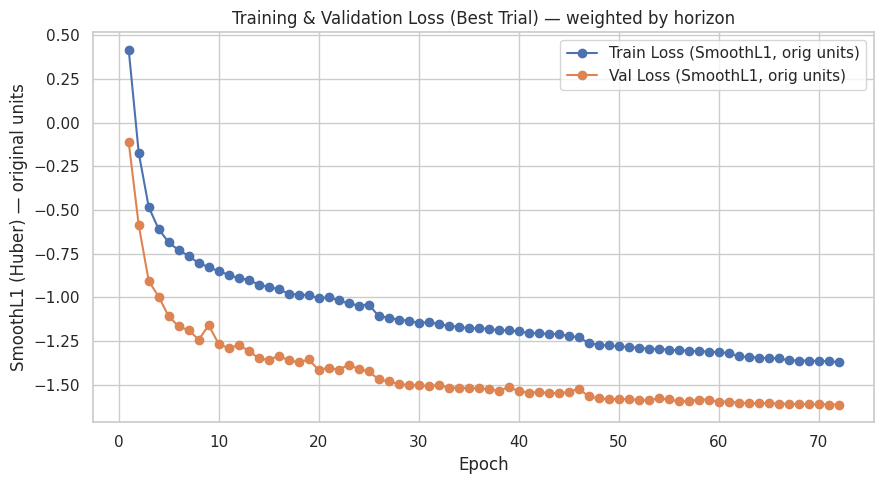

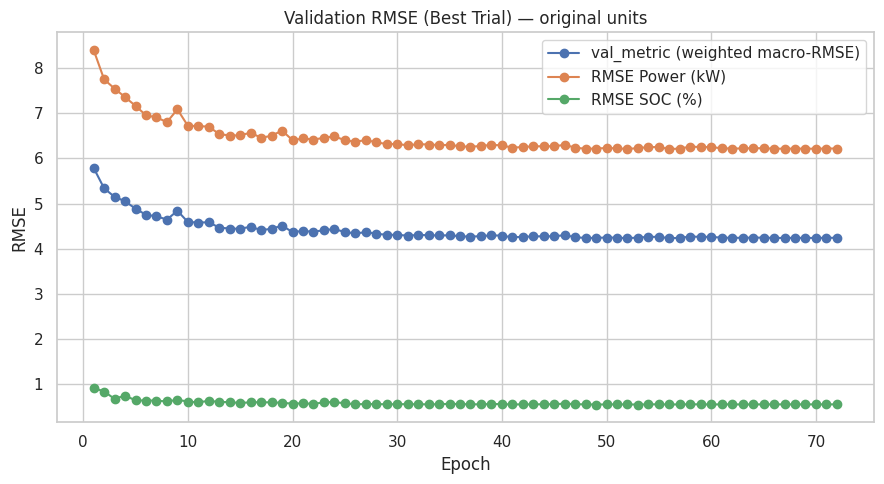

In [18]:
# --- Get & clean history for the best trial ---
best = results.get_best_result(metric="val_metric", mode="min")
print(f"The best model's metrics were: {best.metrics}")
hist = best.metrics_dataframe.copy()

# choose a "time" column for stable ordering
time_col = (
    "time_total_s" if "time_total_s" in hist.columns else
    ("timestamp" if "timestamp" in hist.columns else
     ("training_iteration" if "training_iteration" in hist.columns else "epoch"))
)

# keep the latest report for each epoch (handles pause/resume duplicates)
hist = (hist
        .sort_values(["epoch", time_col])
        .drop_duplicates(subset="epoch", keep="last")
        .sort_values("epoch"))

# make sure epoch is numeric/int for a nice axis
hist["epoch"] = hist["epoch"].astype(int)

# --- Plots ---
plt.figure(figsize=(9,5))
plt.plot(hist["epoch"], hist["train_loss"], label="Train Loss (SmoothL1, orig units)", marker="o")
plt.plot(hist["epoch"], hist["val_loss"],   label="Val Loss (SmoothL1, orig units)",   marker="o")
plt.ylabel("SmoothL1 (Huber) — original units")
plt.xlabel("Epoch")
plt.title("Training & Validation Loss (Best Trial) — weighted by horizon")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(9,5))
plt.plot(hist["epoch"], hist["val_metric"], label="val_metric (weighted macro-RMSE)", marker="o")
if "val_rmse_power" in hist.columns:
    plt.plot(hist["epoch"], hist["val_rmse_power"], label="RMSE Power (kW)", marker="o")
if "val_rmse_soc" in hist.columns:
    plt.plot(hist["epoch"], hist["val_rmse_soc"],   label="RMSE SOC (%)",   marker="o")
plt.ylabel("RMSE")
plt.xlabel("Epoch")
plt.title("Validation RMSE (Best Trial) — original units")
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()




### 3.5 Instantiate & Train/Load Model (Post-Tuning)
After tuning, you can load the best checkpoint and continue with your evaluation.
Here we load the best checkpoint from the best trial and then run your evaluation code.

In [19]:
# Recreate the model with best hyperparams
cfg = best.config
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = MultiHorizonLSTM(
    input_size=len(input_features),
    hidden_dim=int(cfg["hidden_dim"]),
    horizon=HORIZON,
    num_targets=len(target_features),
    num_layers=int(cfg["num_layers"]),
    dropout=float(cfg.get("dropout", 0.0)),
).to(device)

# Load weights from the best checkpoint Ray saved
ckpt = best.checkpoint
ckpt_dir = ckpt.to_directory()
state = torch.load(os.path.join(ckpt_dir, "checkpoint.pt"), map_location=device)
model.load_state_dict(state["model"])
model.eval()

# Save a clean .pth (state_dict only)
torch.save(model.state_dict(), MODEL_PATH)
print(f"Saved best model to: {MODEL_PATH}")


Saved best model to: /home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/Models/LSTM_multihorizon_raytuned_model_6.pth


/tmp/ipykernel_24417/827458116.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(ckpt_dir, "checkpoint.pt"), map_location=device)


 ## 4. Model Evaluation



 **Macro-Averaging**: For each sequence, we compute the MSE across *its* valid time steps \((1 \le i < L - \text{horizon})\) and the entire horizon dimension. Then we average these sequence-level errors across all sequences.



 **Note**: During training we did a *micro-average* (standard approach). Below is an example of how to do the per-sequence macro-average on the test set.

### 4.1 Evaluating the model with macro averaging

In [20]:
def evaluate_model_macro_average(model: nn.Module,
                                 dataset: ChargingSessionDataset,
                                 batch_size: int,
                                 device: torch.device,
                                 power_scaler: MinMaxScaler,
                                 soc_scaler: MinMaxScaler,
                                 ) -> dict:
    """
    Macro-averaged MSE over sequences in *original units*.
    Works whether the model predicts absolutes or residuals; here we assume residuals and
    reconstruct absolute predictions as y_hat_abs = Δy_hat + y(i) in *scaled* space,
    then inverse-scale to kW / %.
    """
    loader = DataLoader(dataset,
                        batch_size=batch_size,
                        collate_fn=session_collate_fn,
                        shuffle=False)
    model.eval()
    seq_mses = []

    with torch.no_grad():
        for X_batch, Y_batch, lengths in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)

            # Model outputs residuals in *scaled* space
            pred_resid, _ = model(X_batch, lengths)                  # (B, T, H, C)

            # Reconstruct ABSOLUTE predictions in *scaled* space
            pred = reconstruct_abs_from_residuals_batch(
                pred_resid, X_batch, IDX_POWER, IDX_SOC
            )                                                        # (B, T, H, C)

            B, T_max, H, C = pred.shape
            for i in range(B):
                seq_len = lengths[i].item()
                if seq_len <= H + 1:
                    continue
                valid_start = 1
                valid_end   = seq_len - H

                seq_pred_scaled = pred[i, :seq_len]                  # (T, H, C), scaled
                seq_true_scaled = Y_batch[i, :seq_len]               # (T, H, C), residuals (!) scaled

                # Reconstruct the true ABSOLUTE (scaled) to match pred:
                # y_true_abs_scaled = Δy_true_scaled + y(i)_scaled
                x_scaled = X_batch[i, :seq_len, [IDX_POWER, IDX_SOC]]    # (T, C)
                x_scaled = x_scaled.unsqueeze(1).expand(-1, H, -1)       # (T, H, C)
                seq_true_scaled_abs = seq_true_scaled + x_scaled

                seq_pred_valid = seq_pred_scaled[valid_start:valid_end]      # (N, H, C)
                seq_true_valid = seq_true_scaled_abs[valid_start:valid_end]

                # Inverse-transform per target (flatten to 2D for transformers)
                pred_power = seq_pred_valid[:, :, 0].contiguous().view(-1, 1).cpu().numpy()
                pred_soc   = seq_pred_valid[:, :, 1].contiguous().view(-1, 1).cpu().numpy()
                true_power = seq_true_valid[:, :, 0].contiguous().view(-1, 1).cpu().numpy()
                true_soc   = seq_true_valid[:, :, 1].contiguous().view(-1, 1).cpu().numpy()

                pred_power_un = power_scaler.inverse_transform(pred_power).ravel()
                pred_soc_un   = soc_scaler.inverse_transform(pred_soc).ravel()
                true_power_un = power_scaler.inverse_transform(true_power).ravel()
                true_soc_un   = soc_scaler.inverse_transform(true_soc).ravel()

                seq_mse = mean_squared_error(
                    np.concatenate([true_power_un, true_soc_un]),
                    np.concatenate([pred_power_un, pred_soc_un])
                )
                seq_mses.append(seq_mse)

    macro_mse = float(np.mean(seq_mses)) if seq_mses else float("nan")
    return {"MacroMSE": macro_mse, "NumSequencesEvaluated": len(seq_mses)}


In [21]:
# Load and evaluate the best model
model = MultiHorizonLSTM(
    input_size=len(input_features),
    hidden_dim=int(cfg["hidden_dim"]),
    horizon=HORIZON,
    num_targets=len(target_features),
    num_layers=int(cfg["num_layers"]),
    dropout=float(cfg.get("dropout", 0.0)),
).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

test_stats = evaluate_model_macro_average(
    model, test_dataset, batch_size=BATCH_SIZE, device=device,
    power_scaler=power_scaler, soc_scaler=soc_scaler
)
print(f"Test Macro-Averaged MSE: {test_stats['MacroMSE']:.4f} "
      f"(across {test_stats['NumSequencesEvaluated']} sequences)")


/tmp/ipykernel_24417/3389415936.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


Test Macro-Averaged MSE: 21.3304 (across 12340 sequences)


 ### 4.2 Plotting Predictions

#### 4.2.1 Plotting Setup and Utility Functions

In [22]:
# Using a single DataClass to fetch data for plotting
@dataclass
class SampleBundle:
    batch_index: int
    sample_index: int
    length: int
    horizon: int
    num_targets: int
    X_sample: torch.Tensor       # (T, input_size)
    Y_sample: torch.Tensor       # (T, H, C)
    P_sample: torch.Tensor       # (T, H, C) (predictions)
    # cached unscaled dynamic inputs for convenience
    true_power_unscaled: np.ndarray  # (T,)
    true_soc_unscaled:   np.ndarray  # (T,)

def _get_nth_batch(loader, n: int):
    """Returns the nth batch from a DataLoader"""
    it = iter(loader)
    for _ in range(n):
        next(it)
    return next(it)

@torch.no_grad()
def fetch_sample_bundle(model: torch.nn.Module,
                        loader: torch.utils.data.DataLoader,
                        batch_index: int,
                        sample_index: int,
                        device: torch.device,
                        power_scaler,
                        soc_scaler) -> SampleBundle:
    """
    Pulls one batch, runs the model, slices out the chosen sample,
    and returns all tensors on CPU for plotting.
    """
    model.eval()
    X_batch, Y_batch, lengths = _get_nth_batch(loader, batch_index)
    if sample_index >= X_batch.shape[0]:
        raise IndexError(f"sample_index {sample_index} out of range for batch {batch_index} "
                         f"(batch size = {X_batch.shape[0]}).")

    # Move batch to device, run model
    X_dev = X_batch.to(device, non_blocking=True)
    P_dev, _ = model(X_dev, lengths)          # (B, T_max, H, C)

    # Slice chosen sample and trim to its true length
    T = lengths[sample_index].item()
    P_s = P_dev[sample_index, :T].cpu()       # (T, H, C)
    Y_s = Y_batch[sample_index, :T].cpu()     # (T, H, C)
    X_s = X_batch[sample_index, :T].cpu()     # (T, input_size)

    H = P_s.shape[1]
    C = P_s.shape[2]

    # Unscale the dynamic inputs for convenience
    power_true = power_scaler.inverse_transform(X_s[:, [IDX_POWER]].numpy()).ravel()
    soc_true   = soc_scaler.inverse_transform(  X_s[:, [IDX_SOC  ]].numpy()).ravel()

    return SampleBundle(
        batch_index=batch_index,
        sample_index=sample_index,
        length=T,
        horizon=H,
        num_targets=C,
        X_sample=X_s,
        Y_sample=Y_s,
        P_sample=P_s,
        true_power_unscaled=power_true,
        true_soc_unscaled=soc_true,
    )

def _valid_time_bounds(T: int, H: int):
    """Valid i for horizon forecasting with your masking: 1 <= i < T - H."""
    start = 1
    end   = max(1, T - H)  # exclusive upper bound when used as Python slice end
    return start, end


In [23]:
test_sampler  = BucketBatchSampler(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, collate_fn=session_collate_fn, 
                          num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

In [24]:
BATCH_INDEX  = 30
SAMPLE_INDEX = 0
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

bundle = fetch_sample_bundle(
    model=model,
    loader=test_loader,
    batch_index=BATCH_INDEX,
    sample_index=SAMPLE_INDEX,
    device=device,
    power_scaler=power_scaler,
    soc_scaler=soc_scaler
)

#### 4.2.2 Plotting input-output pairs at time t for a single session

In [25]:
# Plots unscaled X values from t_0 -> t_i vs unscaled prediction for t_i+1
# ---------------------------------------------------------
# Inputs (same units as target) → single output @ horizon
# Shared Y axis (original units), red/blue "×" markers
# ---------------------------------------------------------
def plot_inputs_to_single_output_grid(
    bundle: SampleBundle,
    i_list: list[int],
    horizon: int = 1,                 # 1..H
    target: str = "power",            # {"power","soc"}
    features_to_show: list[str] | None = None,   # default enforces same-units
    power_scaler=None,
    soc_scaler=None,
    window_len: int | None = 30,      # show last N steps up to i0; None = from start
    ncols: int = 3,
    right_pad_steps: float = 1.8,     # extra x padding to the right
    annotate: bool = True,
    enforce_same_units: bool = True,  # <-- ensure inputs match target units
):
    assert target in {"power", "soc"}
    H, T = bundle.horizon, bundle.length
    h = max(1, min(horizon, H))  # clamp
    start_valid, end_valid_excl = _valid_time_bounds(T, H)
    if not i_list:
        raise ValueError("i_list cannot be empty.")

    # Clamp i_list to valid emission indices
    clamped = []
    for i0 in i_list:
        i_clamped = min(max(i0, start_valid), end_valid_excl - 1)
        if start_valid <= i_clamped < end_valid_excl:
            clamped.append(i_clamped)
    if not clamped:
        raise ValueError(f"No valid i0 in i_list. Valid range is 1 .. {T - H - 1}.")

    # --- Prepare UNscaled series ---
    # dynamic inputs already cached in original units:
    power_unscaled = bundle.true_power_unscaled
    soc_unscaled   = bundle.true_soc_unscaled

    feats_map = {
        "power": power_unscaled,
        "soc":   soc_unscaled,
        # (temp/nominal_power omitted deliberately when enforcing same-units)
    }

    if features_to_show is None:
        features_to_show = ["power"] if target == "power" else ["soc"]

    if enforce_same_units:
        allowed = {"power"} if target == "power" else {"soc"}
        features_to_show = [f for f in features_to_show if f in allowed]
        if not features_to_show:
            features_to_show = list(allowed)
    else:
        # If you disable enforcement and include mixed units, the axis will still be shared
        # (not recommended). We silently drop unknown names.
        features_to_show = [f for f in features_to_show if f in feats_map]

    # Target scaler for output points
    t_scaler = power_scaler if target == "power" else soc_scaler
    target_idx = 0 if target == "power" else 1
    y_label = "Power (kW)" if target == "power" else "SOC (%)"

    # Layout
    n = len(clamped)
    ncols = max(1, ncols)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2*ncols, 4.2*nrows), squeeze=False)
    palette = sns.color_palette("deep", n_colors=len(features_to_show))

    for ax, i0 in zip(axes.ravel(), clamped):
        # Window
        if window_len is None:
            w0, w1 = 0, i0 + 1
        else:
            w0 = max(0, i0 - window_len + 1)
            w1 = i0 + 1
        tt = np.arange(w0, w1)

        # Plot inputs on the SAME axis (original units)
        ymins, ymaxs = [], []
        for ci, f in enumerate(features_to_show):
            series = feats_map[f][w0:w1]
            ax.plot(tt, series, label=f, linewidth=2, color=palette[ci])
            ymins.append(series.min()); ymaxs.append(series.max())

        # Output point (same axis)
        t_pred = i0 + h
        # reconstruct abs, still in scaled space)
        P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)  # (T, H, C), scaled
        y_pred = P_abs[i0, h-1, target_idx].numpy().reshape(1, 1)
        # True absolute (scaled): Δy_true + y(i)
        base_i = bundle.X_sample[i0, [IDX_POWER, IDX_SOC]][target_idx].item()
        y_true = (bundle.Y_sample[i0, h-1, target_idx].item() + base_i)
        y_true = np.array([[y_true]], dtype=np.float32)

        # Inverse transform
        y_pred = t_scaler.inverse_transform(y_pred).ravel()[0] if t_scaler else float(y_pred.ravel()[0])
        y_true = t_scaler.inverse_transform(y_true).ravel()[0] if t_scaler else float(y_true.ravel()[0])
    
        # markers
        ax.scatter([t_pred], [y_pred], s=120, marker="x", linewidths=2.5, color="tab:red",  zorder=5, label="Pred")
        ax.scatter([t_pred], [y_true], s=120, marker="x", linewidths=2.5, color="tab:blue", zorder=5, label="True")

        if annotate:
            ax.annotate(f"{y_pred:.2f}", (t_pred, y_pred), textcoords="offset points", xytext=(6, 8),
                        fontsize=8, color="tab:red")
            ax.annotate(f"{y_true:.2f}", (t_pred, y_true), textcoords="offset points", xytext=(6, -14),
                        fontsize=8, color="tab:blue")

        # y-lims covering inputs + outputs with padding
        ymins.append(min(y_pred, y_true)); ymaxs.append(max(y_pred, y_true))
        y_lo, y_hi = min(ymins), max(ymaxs)
        span = max(1e-9, y_hi - y_lo)
        pad = 0.08 * span if span > 0 else 0.5  # small default pad if flat
        ax.set_ylim(y_lo - pad, y_hi + pad)

        # x-lims with right padding
        ax.axvline(i0, color="black", linestyle=":", linewidth=1.8)
        ax.set_xlim(min(w0, t_pred), max(w1 - 1, t_pred) + right_pad_steps)

        ax.set_title(f"i₀={i0}, H={h} → t={t_pred} | batch {bundle.batch_index}, sample {bundle.sample_index}")
        ax.set_xlabel("Time index")
        ax.set_ylabel(y_label)
        ax.grid(True); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.legend(fontsize=8, loc="upper left")

    # Hide extra axes if grid not full
    for k in range(len(clamped), nrows*ncols):
        axes.ravel()[k].set_axis_off()

    fig.suptitle(f"Inputs → Single {target.upper()} output @ horizon H={h} (shared axis)", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()


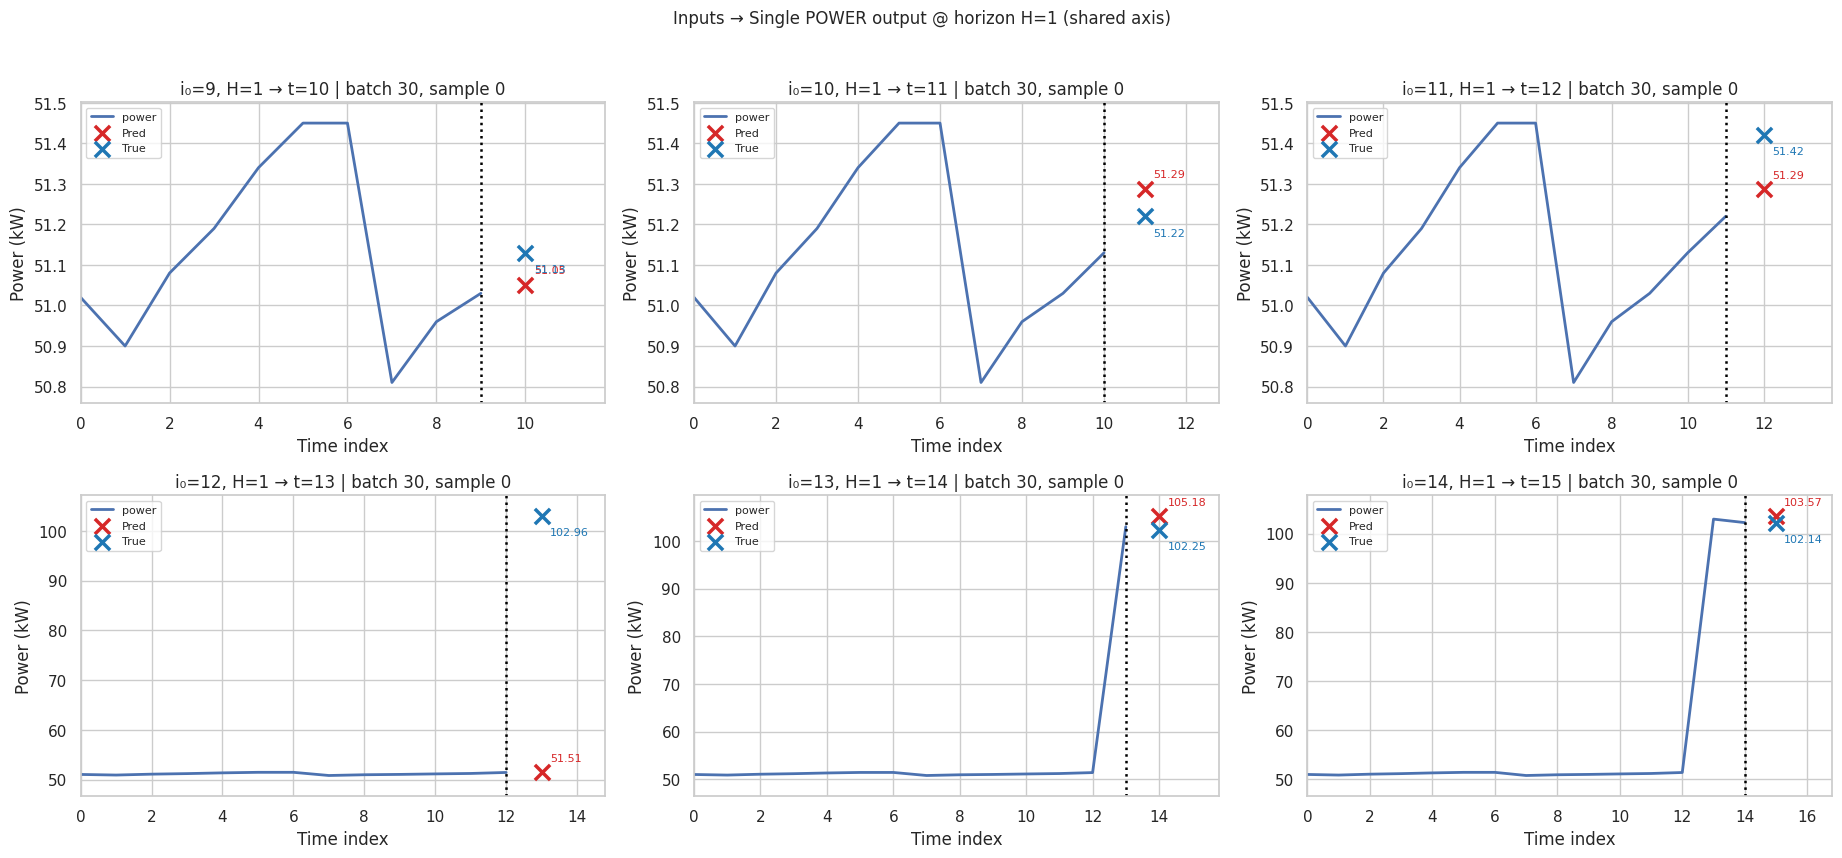

In [26]:
# Plotting
i_list = [9, 10, 11, 12, 13, 14]
plot_inputs_to_single_output_grid(
    bundle,
    i_list=i_list,
    horizon=1,
    target="power",
    features_to_show=["power"],     # same units as target
    power_scaler=power_scaler,
    soc_scaler=soc_scaler,
    window_len=30,
    ncols=3,
    enforce_same_units=True         # keeps inputs consistent with target units
)


#### 4.2.3 Plotting Complete Multi-Horizon Predictions for a Single Session

In [27]:
# Given a sample session, plot predictions for all time steps per horizon
def plot_full_session(bundle, power_scaler, soc_scaler, target="power", title_suffix=""):
    assert target in {"power","soc"}
    T, H = bundle.length, bundle.horizon
    t = np.arange(T)
    idx = 0 if target=="power" else 1
    scaler = power_scaler if target=="power" else soc_scaler
    true = bundle.true_power_unscaled if idx==0 else bundle.true_soc_unscaled

    plt.figure(figsize=(10,5))
    sns.lineplot(x=t, y=true, color="black", linewidth=2.5, label=f"True {target.title()}")

    palette = sns.color_palette("deep", n_colors=H)
    for h0 in range(H):                 # h0 is 0-based; horizon = h0+1
        i_valid = np.arange(1, T - (h0+1))           # i ∈ [1, T-h-1]
        t_abs   = i_valid + (h0+1)
        P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)  # scaled
        preds = P_abs[i_valid, h0, idx].numpy().reshape(-1, 1)
        preds = scaler.inverse_transform(preds).ravel()

        # dashed line + markers at *actual* times
        sns.lineplot(x=t_abs, y=preds, linestyle="--", linewidth=1.8,
                     color=palette[h0], label=f"Horizon={h0+1}", marker="o", markersize=3)
        # faint scatter to emphasize discrete positions
        plt.scatter(t_abs, preds, s=10, color=palette[h0], alpha=0.5)

    plt.title(f"{target.upper()} predictions on a single session\nbatch {bundle.batch_index}, sample {bundle.sample_index}{title_suffix}")
    plt.xlabel("Time index"); plt.ylabel("Power (kW)" if idx==0 else "SOC (%)")
    plt.grid(True); plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.legend(); plt.tight_layout(); plt.show()

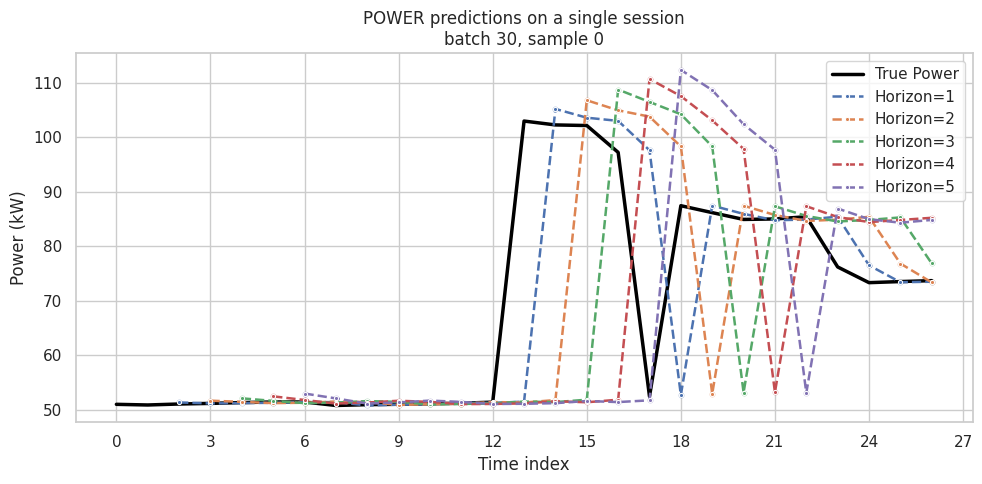

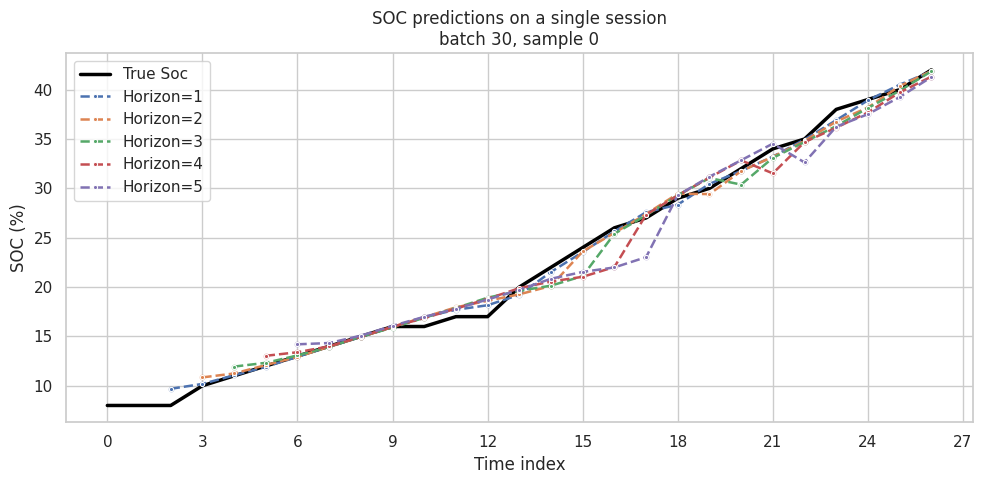

In [28]:
# 2) Full-session plots
plot_full_session(bundle, power_scaler, soc_scaler, target="power")
plot_full_session(bundle, power_scaler, soc_scaler, target="soc")

#### 4.2.4 Plotting Complete Power Predictions for Multiple Sample Sessions

In [29]:
# Plots predictions of multiple samples in a grid: 
# Sample session id along the rows, horizon value along the columns
def plot_grid_by_horizon(bundles: list,
                         power_scaler,
                         soc_scaler,
                         target: str = "power"):
    """
    One column per bundle (session), one row per horizon.
    True series (black) + predictions for that horizon (dashed with markers),
    aligned so a forecast emitted at i for horizon h lands at t = i + h.
    """
    assert target in {"power", "soc"}
    H = bundles[0].horizon
    target_idx = 0 if target == "power" else 1
    scaler = power_scaler if target == "power" else soc_scaler

    ncols = len(bundles)
    fig, axes = plt.subplots(nrows=H, ncols=ncols,
                             figsize=(5*ncols, 4*H), squeeze=False, sharex=False, sharey=False)
    if ncols == 1:
        axes = axes[:, None]

    palette = sns.color_palette("deep", n_colors=H)

    for col, b in enumerate(bundles):
        T = b.length
        t_true = np.arange(T)  # 0..T-1 (same convention as full-session)
        true_unscaled = b.true_power_unscaled if target_idx == 0 else b.true_soc_unscaled

        for h0 in range(H):                     # h0: 0-based horizon index
            h1 = h0 + 1                         # horizon step (1..H)
            ax = axes[h0, col]

            # valid emission indices so that i + h1 <= T-1
            i_valid = np.arange(1, T - h1)      # i ∈ [1, T-h1-1] inclusive
            if i_valid.size == 0:
                ax.text(0.5, 0.5, "No valid preds", ha="center", va="center")
                ax.set_axis_off()
                continue

            # absolute times where those predictions land
            t_pred = i_valid + h1

            # predictions (inverse-scaled)
            P_abs = reconstruct_abs_from_bundle(b, IDX_POWER, IDX_SOC)
            preds = P_abs[i_valid, h0, target_idx].numpy().reshape(-1, 1)
            preds_unscaled = scaler.inverse_transform(preds).ravel()

            # plot truth and preds
            sns.lineplot(x=t_true, y=true_unscaled, color="black",
                         linewidth=2, label="True", ax=ax)
            sns.lineplot(x=t_pred, y=preds_unscaled, linestyle="--",
                         linewidth=2, color=palette[h0], label=f"Pred (H={h1})",
                         marker="o", markersize=3, ax=ax)

            ax.set_title(f"Batch {b.batch_index}, Sample {b.sample_index} | H={h1}, T={T}")
            ax.set_xlabel("Time index")
            ax.set_ylabel("POWER (kW)" if target_idx == 0 else "SOC (%)")
            ax.grid(True)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()



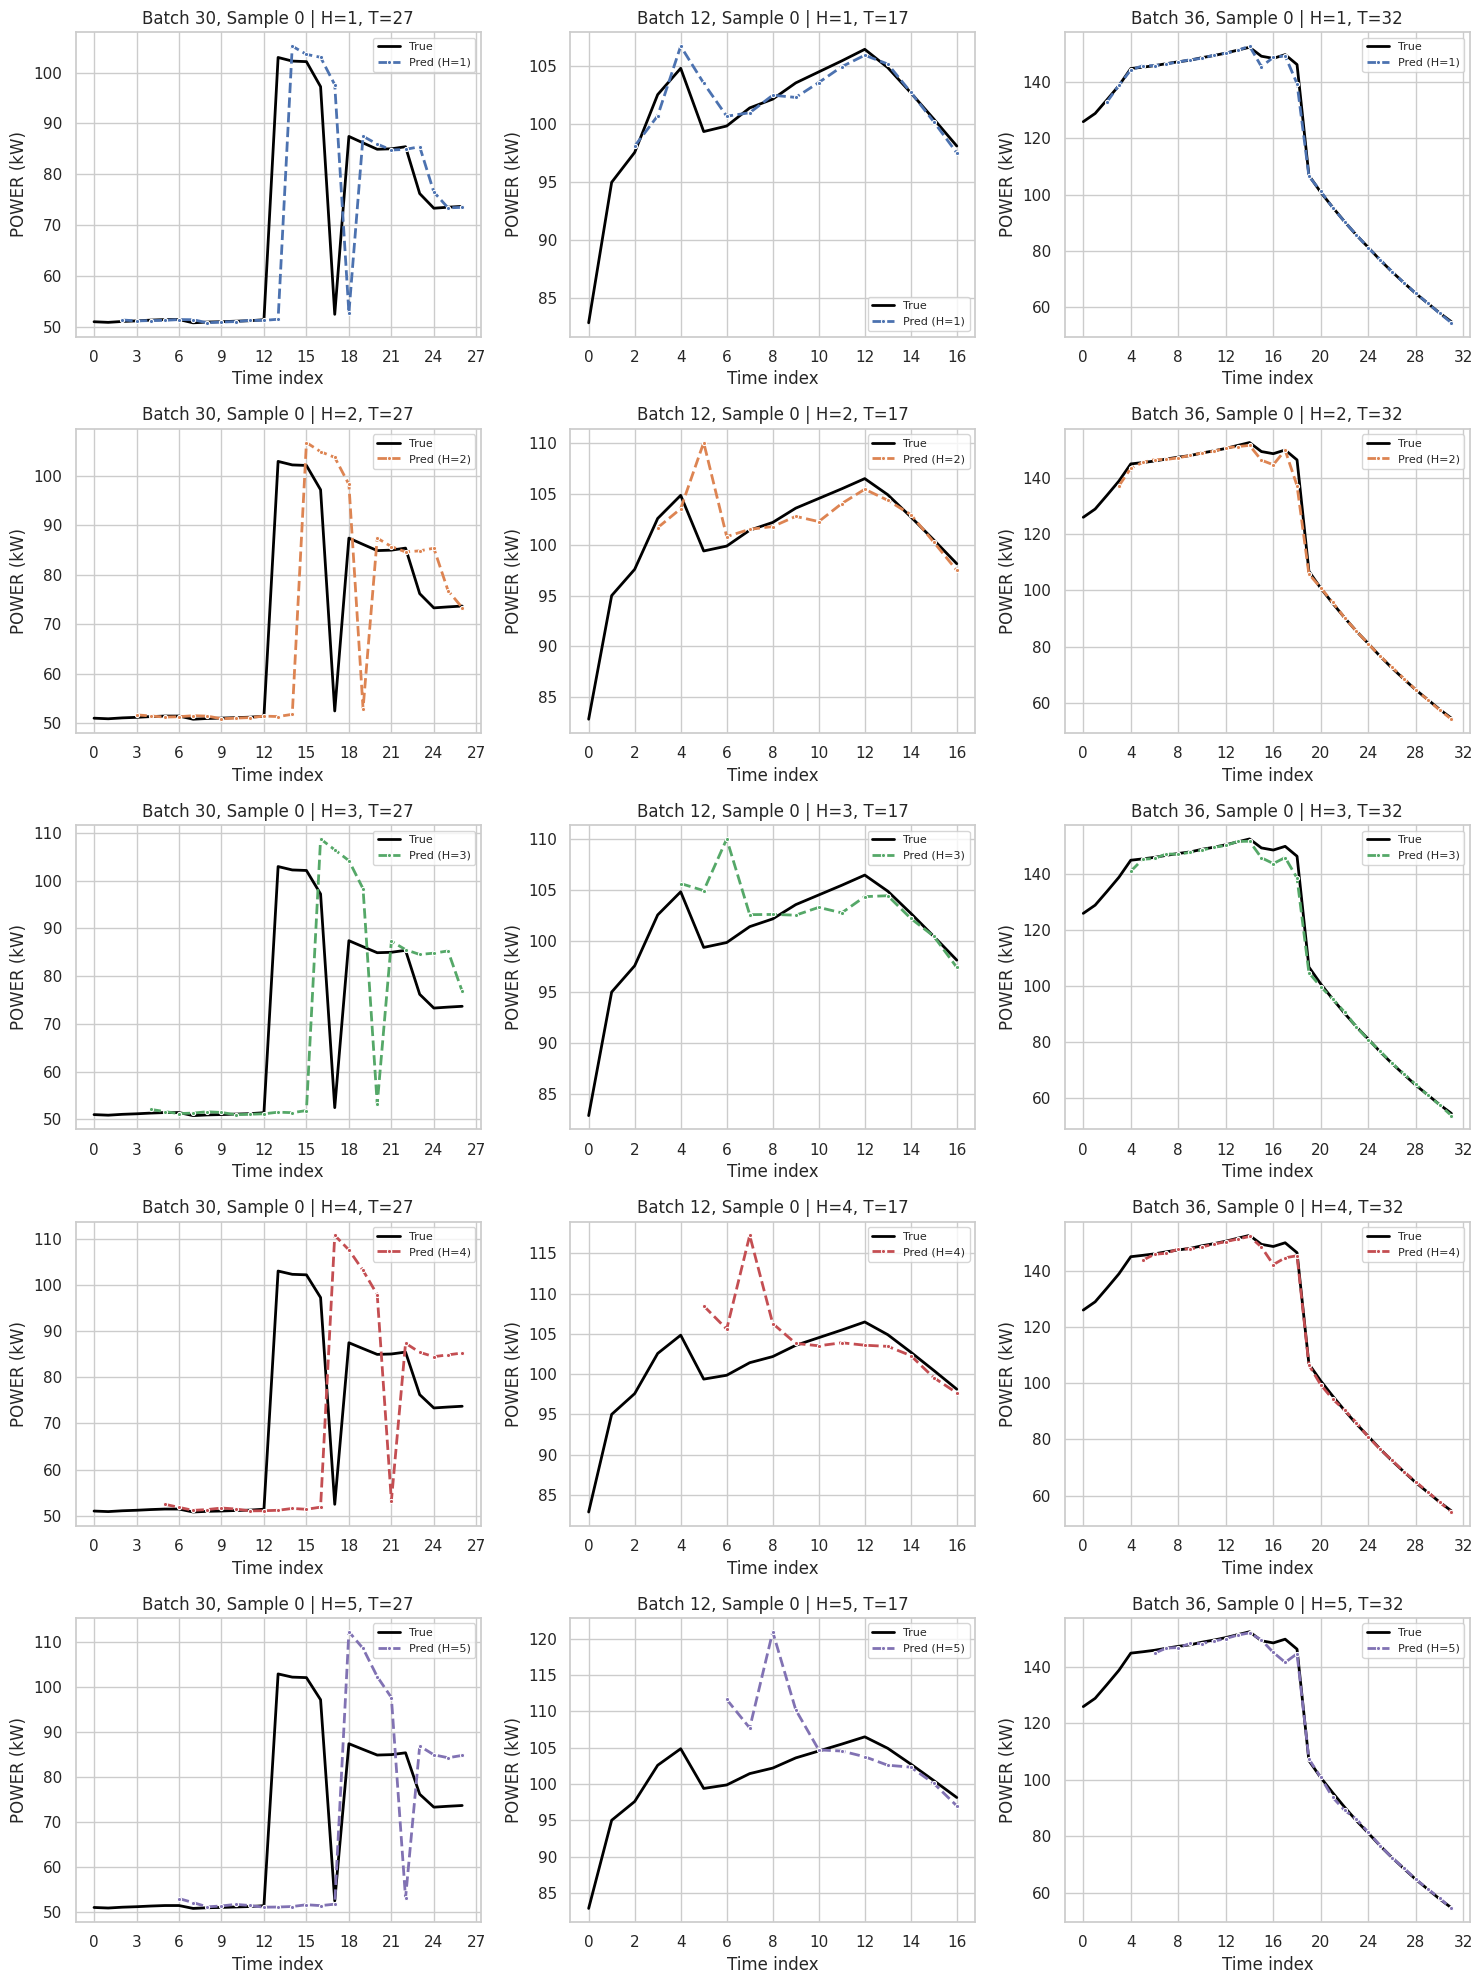

In [30]:
# Plotting
bundles = [
    fetch_sample_bundle(model, test_loader, BATCH_INDEX, SAMPLE_INDEX, device, power_scaler, soc_scaler),
    fetch_sample_bundle(model, test_loader, 12, 0, device, power_scaler, soc_scaler),
    fetch_sample_bundle(model, test_loader, 36, 0, device, power_scaler, soc_scaler),
]
plot_grid_by_horizon(bundles, power_scaler, soc_scaler, target="power")


## Anomaly Detection